In [ ]:
#importing the libraries

import warnings
import numpy as np
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

%matplotlib inline
warnings.filterwarnings('ignore')

# **1. Data Preprocessing**

In [ ]:
# Set random seed for reproducibility
np.random.seed(42)

In [ ]:
# Load the dataset
data2 = pd.read_csv('/content/diverse_synthetic_customer_segmentation_dataset (1).csv')

# Display the first few rows of the dataset
data2.head()


,CustomerID,Age,Gender,Annual Income (k$),Spending Score (1-100),Tenure,Purchase Frequency,Average Transaction Value,Product Category Preference,Online Activity
0,1,27,0,29,86,4,24,88,0,100
1,2,29,0,25,85,2,23,112,0,71
2,3,18,0,24,70,2,20,29,0,100
3,4,24,0,31,66,1,26,42,0,94
4,5,22,0,27,74,4,25,47,0,98


In [ ]:
# Check the structure and summary of the dataset
data2.info()
data2.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   CustomerID                   500 non-null    int64
 1   Age                          500 non-null    int64
 2   Gender                       500 non-null    int64
 3   Annual Income (k$)           500 non-null    int64
 4   Spending Score (1-100)       500 non-null    int64
 5   Tenure                       500 non-null    int64
 6   Purchase Frequency           500 non-null    int64
 7   Average Transaction Value    500 non-null    int64
 8   Product Category Preference  500 non-null    int64
 9   Online Activity              500 non-null    int64
dtypes: int64(10)
memory usage: 39.2 KB


,CustomerID,Age,Gender,Annual Income (k$),Spending Score (1-100),Tenure,Purchase Frequency,Average Transaction Value,Product Category Preference,Online Activity
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,40.534000,1.000000,60.498000,57.386000,6.282000,17.268000,274.740000,0.750000,60.104000
std,144.481833,12.246011,0.707815,24.440226,17.215276,3.115427,7.125006,151.537135,0.829987,23.780922
min,1.000000,18.000000,0.000000,15.000000,11.000000,1.000000,1.000000,10.000000,0.000000,8.000000
25%,125.750000,30.000000,0.750000,41.000000,46.000000,4.000000,12.000000,145.000000,0.000000,40.000000
50%,250.500000,41.000000,1.000000,60.000000,56.000000,6.000000,17.000000,254.500000,0.500000,61.000000
75%,375.250000,50.000000,1.250000,80.000000,70.000000,9.000000,23.000000,398.000000,1.250000,80.000000
max,500.000000,69.000000,2.000000,117.000000,100.000000,12.000000,30.000000,599.000000,2.000000,100.000000


In [ ]:
#Check the count of rows and columns
data2.shape

(500, 10)

In [ ]:
#Check foor missing valuues
data2.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Annual Income (k$),0
Spending Score (1-100),0
Tenure,0
Purchase Frequency,0
Average Transaction Value,0
Product Category Preference,0
Online Activity,0


In [ ]:
# Check for infinite values
print("Infinite values in each column:")
print(np.isinf(data2).sum())


Infinite values in each column:
CustomerID                     0
Age                            0
Gender                         0
Annual Income (k$)             0
Spending Score (1-100)         0
Tenure                         0
Purchase Frequency             0
Average Transaction Value      0
Product Category Preference    0
Online Activity                0
dtype: int64


**Encoding Categorical Variables**

In [ ]:
#Identify categorical variables

categorical_columns = [column for column in data2.columns if len(data2[column].unique()) <= 5]
print(categorical_columns)

['Gender', 'Product Category Preference']


In [ ]:
# Encode categorical features
# One-Hot Encoding 'Gender' and 'Product Category Preference'
data2 = pd.get_dummies(data2, columns=['Gender', 'Product Category Preference'])
data2.head()

# The resulting dataframe will have new binary columns for each category in these features.
# Now, the dataset is ready for scaling (only numeric features).


,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Tenure,Purchase Frequency,Average Transaction Value,Online Activity,Gender_0,Gender_1,Gender_2,Product Category Preference_0,Product Category Preference_1,Product Category Preference_2
0,1,27,29,86,4,24,88,100,True,False,False,True,False,False
1,2,29,25,85,2,23,112,71,True,False,False,True,False,False
2,3,18,24,70,2,20,29,100,True,False,False,True,False,False
3,4,24,31,66,1,26,42,94,True,False,False,True,False,False
4,5,22,27,74,4,25,47,98,True,False,False,True,False,False


**Standardizing the Features**

In [ ]:
# Initialize the standard scaler
scaler = StandardScaler()

# Drop 'CustomerID' as it is a unique identifier and doesn't contribute to clustering
numerical_features = data2.drop(columns=['CustomerID'])
scaled_features = scaler.fit_transform(numerical_features)

# Convert back to DataFrame
data2_scaled = pd.DataFrame(scaled_features, columns=numerical_features.columns)

data2_scaled.head()

,Age,Annual Income (k$),Spending Score (1-100),Tenure,Purchase Frequency,Average Transaction Value,Online Activity,Gender_0,Gender_1,Gender_2,Product Category Preference_0,Product Category Preference_1,Product Category Preference_2
0,-1.106283,-1.290068,1.663793,-0.733217,0.945788,-1.233539,1.679327,1.732051,-1.0,-0.57735,1.0,-0.57735,-0.57735
1,-0.942801,-1.453896,1.605647,-1.375827,0.805296,-1.075004,0.458641,1.732051,-1.0,-0.57735,1.0,-0.57735,-0.57735
2,-1.841952,-1.494853,0.733455,-1.375827,0.383822,-1.623273,1.679327,1.732051,-1.0,-0.57735,1.0,-0.57735,-0.57735
3,-1.351506,-1.208153,0.500871,-1.697131,1.226770,-1.537399,1.426772,1.732051,-1.0,-0.57735,1.0,-0.57735,-0.57735
4,-1.514988,-1.371982,0.966040,-0.733217,1.086279,-1.504371,1.595142,1.732051,-1.0,-0.57735,1.0,-0.57735,-0.57735


# **2. K-means Clustering**

In [ ]:
#Applying K-Means Clustering with Initial Clusters
from sklearn.cluster import KMeans

# Set an initial number of clusters (e.g., 3)
initial_clusters = 3

# Initialize and fit the KMeans model
kmeans = KMeans(n_clusters=initial_clusters, random_state=42)
clusters = kmeans.fit_predict(data2_scaled)

# Add the cluster labels to the original DataFrame
data2['Cluster'] = clusters


# Inspect cluster centers
print(kmeans.cluster_centers_)


[[ 0.4291404   0.39556396 -0.67298318  0.40548655 -0.64401223  0.48379791
   0.01363801 -0.57735027  1.         -0.57735027  0.          0.57735027
  -0.57735027]
 [-1.23445302 -1.20782575  1.23862863 -1.35783372  0.95702691 -1.14444233
   1.22977822  1.73205081 -1.         -0.57735027  1.         -0.57735027
  -0.57735027]
 [ 0.37617222  0.41669784  0.10733774  0.54686062  0.33099756  0.1768465
  -1.25705424 -0.57735027 -1.          1.73205081 -1.         -0.57735027
   1.73205081]]


In [ ]:
# Display the first few rows with cluster labels
data2.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Tenure,Purchase Frequency,Average Transaction Value,Online Activity,Gender_0,Gender_1,Gender_2,Product Category Preference_0,Product Category Preference_1,Product Category Preference_2,Cluster
0,1,27,29,86,4,24,88,100,True,False,False,True,False,False,1
1,2,29,25,85,2,23,112,71,True,False,False,True,False,False,1
2,3,18,24,70,2,20,29,100,True,False,False,True,False,False,1
3,4,24,31,66,1,26,42,94,True,False,False,True,False,False,1
4,5,22,27,74,4,25,47,98,True,False,False,True,False,False,1


**Initial clusters = 3 was assigned because from research, 3 clusters are common are usually computationally efficient. The initial cluster centers revealed distinct customer groups. However, to ensure that the optimal number of clusters was chosen, further evaluation was necessary.**

# **3. Determining the Optimal Number of Clusters**

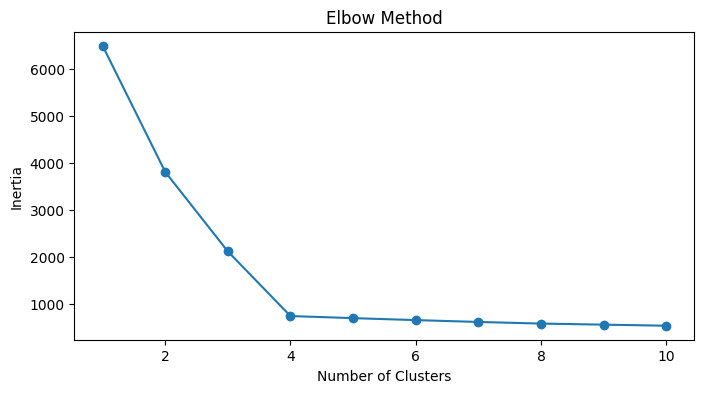

In [ ]:
# Elbow Method

inertia = []

# Test different numbers of clusters
for n in range(1, 11):
    kmeans = KMeans(n_clusters=n, random_state=42)
    kmeans.fit(data2_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

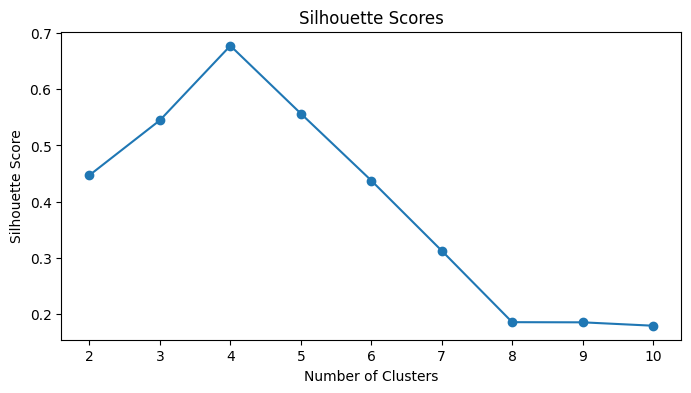

In [ ]:
# Silhouette Score
from sklearn.metrics import silhouette_score

# Initialize a list to store silhouette scores for different numbers of clusters
silhouette_scores = []
for n in range(2, 11):
    kmeans = KMeans(n_clusters=n, random_state=42)
    labels = kmeans.fit_predict(data2_scaled)
    score = silhouette_score(data2_scaled, labels)
    silhouette_scores.append(score)

# Plot the silhouette scores
plt.figure(figsize=(8, 4))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

**The Elbow Method was used to plot the inertia (within-cluster sum of squares) against the number of clusters. The plot revealed a significant decrease in inertia up to 4 clusters, after which the rate of decrease slowed. This suggested that 4 clusters might be optimal.**

**To determine the range to loop through for the Elbow Method, a common rule of thumb approach was applied. Which is that the number of clusters ( k ) should not exceed the square root of half the number of data points (in this case: 500).**

**The Silhouette Score, which measures how similar a data point is to its own cluster compared to other clusters, was calculated for different numbers of clusters. The highest silhouette score was observed with 4 clusters, confirming that this was the most appropriate choice**.

**Based on the evaluation metrics, K-means clustering will be re-run with 4 clusters.**

In [ ]:
#Re-run the K-means clustering with the optimal number of clusters

# Deciding the optimal cluster from the plots
optimal_clusters = 4

# Apply KMeans with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
kmeans.fit(data2_scaled)

# Assign the new cluster labels to the dataset
data2['Cluster'] = kmeans.labels_

# Display the first few rows with the final cluster labels
data2.head()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Tenure,Purchase Frequency,Average Transaction Value,Online Activity,Gender_0,Gender_1,Gender_2,Product Category Preference_0,Product Category Preference_1,Product Category Preference_2,Cluster
0,1,27,29,86,4,24,88,100,True,False,False,True,False,False,2
1,2,29,25,85,2,23,112,71,True,False,False,True,False,False,2
2,3,18,24,70,2,20,29,100,True,False,False,True,False,False,2
3,4,24,31,66,1,26,42,94,True,False,False,True,False,False,2
4,5,22,27,74,4,25,47,98,True,False,False,True,False,False,2


In [ ]:
data2.tail(10)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Tenure,Purchase Frequency,Average Transaction Value,Online Activity,Gender_0,Gender_1,Gender_2,Product Category Preference_0,Product Category Preference_1,Product Category Preference_2,Cluster
490,491,57,103,45,10,21,544,76,False,True,False,True,False,False,1
491,492,49,77,43,10,7,507,86,False,True,False,True,False,False,1
492,493,58,79,39,9,8,479,65,False,True,False,True,False,False,1
493,494,49,89,34,7,20,554,66,False,True,False,True,False,False,1
494,495,55,78,57,12,11,551,72,False,True,False,True,False,False,1
495,496,48,86,41,10,9,495,69,False,True,False,True,False,False,1
496,497,55,79,33,9,15,395,82,False,True,False,True,False,False,1
497,498,62,87,14,10,10,449,65,False,True,False,True,False,False,1
498,499,63,97,31,8,8,489,75,False,True,False,True,False,False,1
499,500,52,95,59,11,10,491,66,False,True,False,True,False,False,1


# **4. PCA and Clustering Visualization**

In [ ]:
#Performing PCA to Reduce Dimensionality

from sklearn.decomposition import PCA

# Initialize PCA to reduce the dataset to 2 dimensions
pca = PCA(n_components=2)

# Fit and transform the scaled data
pca_components = pca.fit_transform(data2_scaled)

# Create a DataFrame with the PCA components for easier visualization
pca_data2 = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])

# Add the cluster labels to the PCA DataFrame
pca_data2['Cluster'] = data2['Cluster']

# Display the explained variance ratio for each principal component
print("Explained Variance Ratio of PCA Components:")
print(pca.explained_variance_ratio_)


Explained Variance Ratio of PCA Components:
[0.45453435 0.27033626]


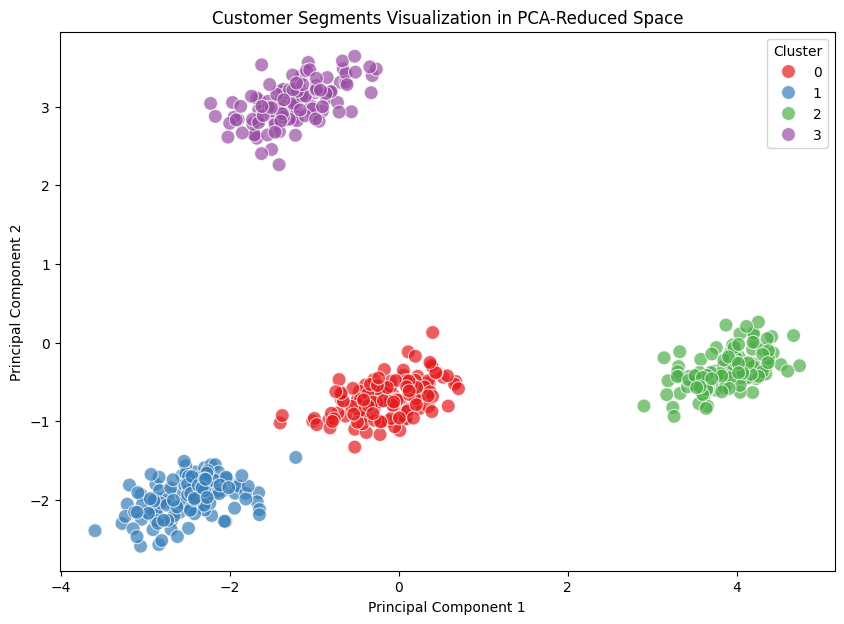

In [ ]:
#Visualizing the Clusters in the PCA Space

import seaborn as sns
import matplotlib.pyplot as plt

# Plot the clusters in the PCA-reduced 2D space
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_data2, palette='Set1', s=100, alpha=0.7)

# Add labels and title to the plot
plt.title('Customer Segments Visualization in PCA-Reduced Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()


# **5. Interpretation of Clusters**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Drop non-numeric columns like 'CustomerID' and refit the scaler on the clustering features
features = data2.drop(columns=['CustomerID'])  # Exclude any non-numeric or irrelevant columns
scaler = StandardScaler()

# Fit the scaler to the feature data
scaler.fit(features)

# Calculate cluster centers (in standardized scale)
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
kmeans.fit(scaler.transform(features))
cluster_centers = kmeans.cluster_centers_

# Inverse transform the cluster centers back to the original scale
original_cluster_centers = scaler.inverse_transform(cluster_centers)

# Create a DataFrame for better readability
cluster_centers_df = pd.DataFrame(original_cluster_centers, columns=features.columns)

# Add a cluster label column for reference
cluster_centers_df['Cluster'] = range(optimal_clusters)

print("Cluster Centers:")
print(cluster_centers_df)


Cluster Centers:
      Age  Annual Income (k$)  Spending Score (1-100)  Tenure  \
0  35.856              49.880                  50.928   5.224   
1  55.712              90.432                  40.696   9.864   
2  25.432              31.008                  78.688   2.056   
3  45.136              70.672                  59.232   7.984   

   Purchase Frequency  Average Transaction Value  Online Activity  \
0              15.136                    204.144           51.152   
1              10.232                    491.816           69.704   
2              24.080                    101.488           89.320   
3              19.624                    301.512           30.240   

       Gender_0  Gender_1      Gender_2  Product Category Preference_0  \
0 -1.665335e-16       1.0 -1.110223e-16                            0.0   
1 -1.665335e-16       1.0 -1.110223e-16                            1.0   
2  1.000000e+00       0.0 -1.110223e-16                            1.0   
3 -1.665335e-16

In [ ]:
# The cluster labels have already been assigned to the dataset
# For reference:
print(data2[['CustomerID', 'Cluster']].head())


   CustomerID  Cluster
0           1        2
1           2        2
2           3        2
3           4        2
4           5        2


# **6. Report**

# **Data Preprocessing**


**The dataset, diverse_synthetic_customer_segmentation_dataset.csv, was loaded. The summary, structure and statistics of the dataset were checked. The dataset was inspected for missing values, infinite values, and data types. No missing values nor infinitite values were found.**

**Categorical variables, such as Gender and Product Category Preference, were encoded using One Hot encoding to convert them into numerical format suitable for clustering.. One Hot encoding was used since the categorical variables are nominal features not ordinal features. Also, the 'drop_first=True' was not used as the model: 'K-means clustering' is not sensitive to multicollinearity. By keeping all dummy variables (not using drop_first=True), I ensured that no information is lost.**

**To ensure that all features contribute equally to the clustering algorithm, the data was standardized using StandardScaler. This transformed each feature to have a mean of 0 and a standard deviation of 1.**

# **PCA Visualization: Show the PCA 2D plot and discuss the clustering results in the reduced space. Did K-means did a good job?**

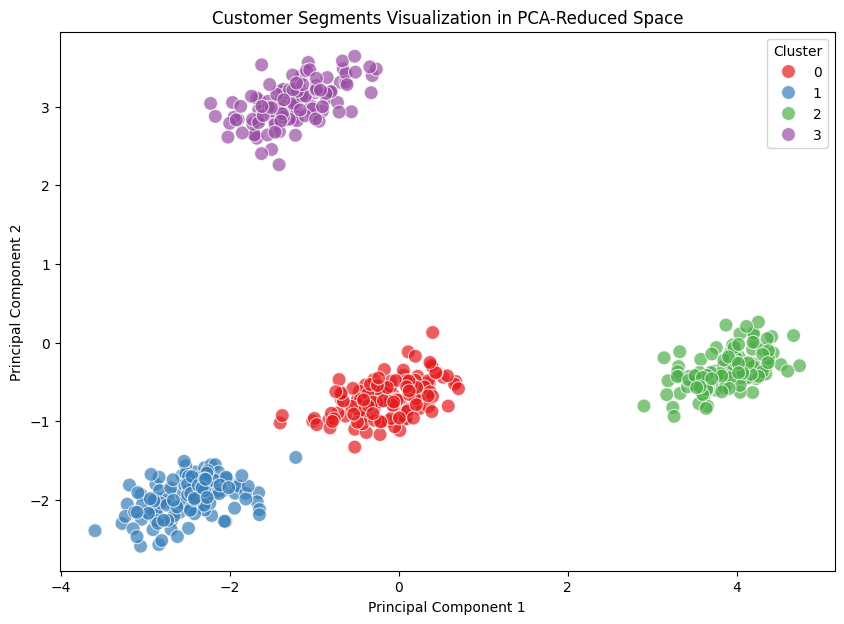

In [ ]:
#Visualizing the Clusters in the PCA Space

import seaborn as sns
import matplotlib.pyplot as plt

# Plot the clusters in the PCA-reduced 2D space
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_data2, palette='Set1', s=100, alpha=0.7)

# Add labels and title to the plot
plt.title('Customer Segments Visualization in PCA-Reduced Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

**Based on the PCA 2D plot, the K-means clustering seems to performe well. The plot shows three distinct clusters (Cluster 0 in blue, Cluster 1 in red, Cluster 2 in green, and Cluster 3 in purple) that are well-separated with just a very minimal (negligible) overlap between clusters 0 and 1. This indicates that K-means was effective in distinguishing between different groups in the PCA-reduced space.**

**The tight grouping of data points within each cluster suggests that the within-group variance is low, which is desirable in clustering. The clear separation between the clusters implies that the between-group variance is high, further indicating a successful clustering outcome.**

**In addition, the first two principal components explain roughly 72.48% of the total variance in the dataset, implying that the PCA can capture a significant proportion of the variance.**

**In summary, the visualization suggests that K-means clustering has done a good job in segmenting the data into coherent groups in the reduced space provided by PCA.**


# **Provide a detailed interpretation of the identified personas, describing key features that distinguish each cluster.**

# **Interpretation of the Key Features**


# **Cluster 0:**

**Age: This cluster has customers with an average age of 35.86 years.**

**Income & Spending: Customers in this cluster have a moderate annual income (49.88k) and a balanced spending score (50.93).**

**Tenure and Online Activity: These customers have been with the company for an average of 5.224 years, and their engagement in online activities is moderate at a rate of 51.52.**

**Gender: All customers in this cluster belong to Gender_1.**

**Product Preference: This group prefers the first product category (Product Category Preference_0).**


# **Cluster 1:**

**Age: Older customers with an average age of 55.71 years.**

**Income & Spending: This group is the wealthiest with an average income of 90.43k and has the least spending score (40.69).**

**Tenure: They have been with the company for the longest- 9.864 years on average, and have an above-average online activity engagement of 69.704.**

**Gender: All customers in this cluster belong to Gender_1 as well.**

**Product Preference: They have a strong preference for Product Category Preference_0.**


# **Cluster 2:**

**Age: This cluster is younger, with an average age of 25.43 years.**

**Income & Spending: They have a lower average income (31.08k) but a very high spending score (78.688).**

**Tenure: Relatively new customers, with an average tenure of 2.056 years but the highest online activity engagement of 89.32.**

**Gender: Exclusively Gender_0.**

**Product Preference: Strong preference for Product Category Preference_0.**


# **Cluster 3:**

**Age: Slightly older customers, with an average age of 45.136 years.**

**Income & Spending: Moderate high income (70.672k) with a slightly above-average spending score (59.232).**

**Tenure: second-longest tenure with the company (7.984 years) and least online activity engagement of 30.24.**

**Gender: Exclusively Gender_2.**

**Product Preference: Preference for Product Category Preference_2.**


# **General Observations**:

**Cluster 0 and Cluster 3 appear to have customers who are relatively similar in terms of age and spending scores but differ significantly in online activity engagement and product preferences.**

**Cluster 1 represents wealthier and older customers who are high spenders.**

**Cluster 2 consists of younger, lower-income, high-spending customers with a specific product preference.**


**Cluster 3 is the only group among the other three groups that belong to Gender_2, and has a strong preference for product_category_2, making them distinct from others. This is also visible from the PCA plot.**



# **Each cluster represents a distinct customer persona:**

**Cluster 0 could represent tech-savvy young adults who are working professionals in their mid-30s and manage their finances carefully by spending moderately. They are drawn to product_category_1 ( maybe electronics or tech-related products in this context). Making them a good target for such products.**

**Cluster 1 might be affluent seniors who are the longest tenured customers but are not willing to spend all the time. However, they purchase premium products, judging from them having the highest transaction value, and are drawn to product_category_0 (maybe fashion products in this context). Their high disposable income makes them an ideal target for premium products.**


**Cluster 2 could include young, possibly urban customers who, despite their lower income, are high spenders. They are relatively new to the company but have the highest engagement with online activity and are drawn to products product_category_0 (maybe fashion products in this context). This group could be targeted with trendy product and oonline promotions**


**Cluster 3 might represent experienced shoppers with a balanced approach to spending, maybe spending on essential services.These customers are middle-aged, likely established in their careers and personal lives, and have been loyal to the company for nearly eight years. They tend to spend moderately but consistently, showing a preference for product_category_2 (maybe essential goods such as groceries). This group can be targeted with family-oriented products and loyalty rewards to maintain their long-term relationship with the company.**
